Fig2C


Fig-regularity: model = all, 100-250, t10, freq_ratio = 1.0
loading data...


data loaded. activity shape: [(18750, 100, 430), (37500, 100, 430), (18750, 100, 430), (37500, 100, 430)], efficacy shape: [(18750, 100, 430), (37500, 100, 430), (18750, 100, 430), (37500, 100, 430)]


original points: rhy=56250, arrhy=56250; plotted points: rhy=1000, arrhy=1000


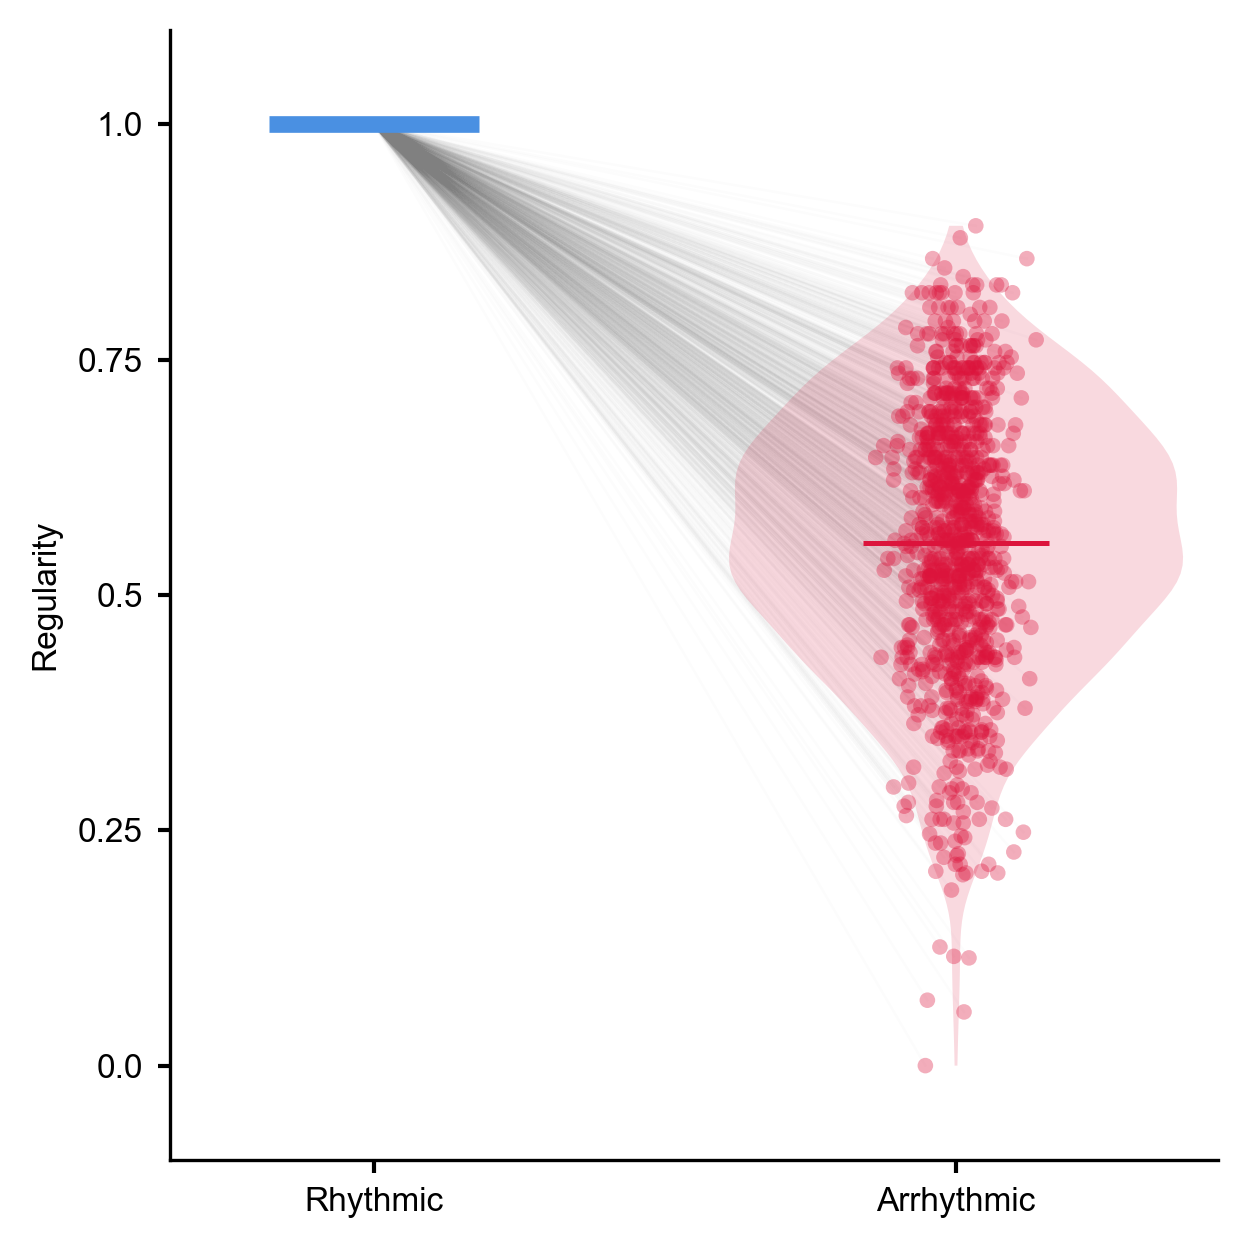

saved to: /home/yangqizhi/Projects/Rhythm/figs/regularity/all, 100-250, t10/Fig2C.pdf


In [1]:
# pyright: reportMissingImports=false
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start_dir: str) -> str:
    current = os.path.abspath(start_dir)
    while True:
        if os.path.isdir(os.path.join(current, "figs-submit")):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError("Could not find project root containing 'figs-submit'.")
        current = parent

PROJECT_ROOT = find_project_root(os.getcwd())
FIGS_SUBMIT_DIR = os.path.join(PROJECT_ROOT, "figs-submit")
if FIGS_SUBMIT_DIR not in sys.path:
    sys.path.insert(0, FIGS_SUBMIT_DIR)

from utils.figure.illustrator import initialize_matplotlib
from utils.activity_loader import (
    load_activity_data_everything,
    load_metadata_and_parameters,
 )
from utils.rhythmicity import compute_fstim_cv

initialize_matplotlib()

freq_ratio = 1.0

_model_ = "all, 100-250, t10"

def resolve_paths(model_name: str):
    if model_name[:3] != "all":
        raise ValueError(f"Unsupported _model_: {model_name}")

    model_to_folder = {
        "all, 100-250, t10": "models/stim_6/change_0_3-m_30_100_3/EIRNN_STSP-uap-dur_100-ioi_250-delay_1000-tvu/time_202601061256-turn_10",
    }

    if model_name not in model_to_folder:
        raise ValueError(f"Unsupported _model_: {model_name}")

    data_parent_folder = model_to_folder[model_name] + "/activity_all_pairs"
    npz_paths = [
        f"{data_parent_folder}/activity_rhy_ch0_all_pairs.npz",
        f"{data_parent_folder}/activity_rhy_ch3_all_pairs.npz",
        f"{data_parent_folder}/activity_arrhy_ch0_all_pairs.npz",
        f"{data_parent_folder}/activity_arrhy_ch3_all_pairs.npz",
    ]
    metadata_json_path = f"{data_parent_folder}/metadata_all_pairs.json"
    return npz_paths, metadata_json_path

def compute_regularities(sample_onset, fixation_duration, time_step):
    fs = 1000 // time_step
    shifted_sample_onset = [so + fixation_duration // time_step for so in sample_onset]

    rhythmicity_l4 = []
    for so in shifted_sample_onset:
        fstim_cv = compute_fstim_cv(so, fs=fs)
        cv_ioi = fstim_cv["CV_IOI"]
        rhythmicity = 1 - cv_ioi
        rhythmicity_l4.append(np.asarray(rhythmicity, dtype=float))
    return rhythmicity_l4

def violin(ax, values, center_x, width=0.78, facecolor="crimson", alpha=0.16):
    vp = ax.violinplot(
        [values],
        positions=[center_x],
        widths=width,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    body = vp["bodies"][0]
    body.set_facecolor(facecolor)
    body.set_edgecolor("none")
    body.set_alpha(alpha)

def plot_rhythmic_vs_arrhythmic(rhythmicity_l4, save_path):
    rhy_vals = np.concatenate([np.asarray(rhythmicity_l4[i], dtype=float).ravel() for i in [0, 1]])
    arrhy_vals = np.concatenate([np.asarray(rhythmicity_l4[i], dtype=float).ravel() for i in [2, 3]])

    rhy_vals = rhy_vals[np.isfinite(rhy_vals)]
    arrhy_vals = arrhy_vals[np.isfinite(arrhy_vals)]

    arrhy_min_r = min(arrhy_vals)
    arrhy_vals = (arrhy_vals - arrhy_min_r) / (1 - arrhy_min_r)

    if len(rhy_vals) == 0 or len(arrhy_vals) == 0:
        raise ValueError("No valid rhythmicity values found for plotting.")

    rng = np.random.default_rng(42)
    if len(rhy_vals) >= 1000:
        rhy_plot_vals = rng.choice(rhy_vals, size=1000, replace=False)
    else:
        rhy_plot_vals = rng.choice(rhy_vals, size=1000, replace=True)

    if len(arrhy_vals) == 1:
        arrhy_plot_vals = np.repeat(arrhy_vals[0], 1000)
    else:
        arrhy_min = np.min(arrhy_vals)
        arrhy_max = np.max(arrhy_vals)
        internal_mask = (arrhy_vals > arrhy_min) & (arrhy_vals < arrhy_max)
        internal_vals = arrhy_vals[internal_mask]
        if len(internal_vals) >= 998:
            arrhy_core = rng.choice(internal_vals, size=998, replace=False)
        elif len(internal_vals) > 0:
            arrhy_core = rng.choice(internal_vals, size=998, replace=True)
        else:
            arrhy_core = rng.choice(arrhy_vals, size=998, replace=True)
        arrhy_plot_vals = np.concatenate([arrhy_core, [arrhy_min, arrhy_max]])

    print(f"original points: rhy={len(rhy_vals)}, arrhy={len(arrhy_vals)}; plotted points: rhy={len(rhy_plot_vals)}, arrhy={len(arrhy_plot_vals)}")

    rhy_ref = 1.0 if np.allclose(rhy_plot_vals, 1.0, atol=1e-6) else float(np.mean(rhy_plot_vals))
    arrhy_mean = float(np.mean(arrhy_plot_vals))

    x_rhy = 0.0
    x_arrhy = 1.0
    x_arrhy_pts = x_arrhy + rng.normal(0.0, 0.045, size=len(arrhy_plot_vals))
    x_rhy_pts = x_rhy + rng.normal(0.0, 0.01, size=len(rhy_plot_vals))
    line_alpha = float(np.clip(25.0 / len(arrhy_plot_vals), 0.01, 0.08))

    fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=300)
    _ = fig
    for x2, y2 in zip(x_arrhy_pts, arrhy_plot_vals):
        ax.plot([x_rhy, x2], [x_arrhy, y2], color="gray", alpha=line_alpha, lw=0.6, zorder=1)

    violin(ax, arrhy_plot_vals, center_x=x_arrhy, width=0.78, facecolor="crimson", alpha=0.16)
    violin(ax, rhy_plot_vals, center_x=x_rhy, width=0.60, facecolor="#4A90E2", alpha=0.12)

    ax.scatter(x_rhy_pts, rhy_plot_vals, s=9, color="#4A90E2", alpha=0.18, edgecolors="none", zorder=2)
    ax.scatter(x_arrhy_pts, arrhy_plot_vals, s=14, color="crimson", alpha=0.35, edgecolors="none", zorder=3)

    ax.hlines(arrhy_mean, x_arrhy - 0.16, x_arrhy + 0.16, colors="crimson", lw=1.2, zorder=4)
    ax.hlines(rhy_ref, x_rhy - 0.18, x_rhy + 0.18, colors="#4A90E2", lw=4.0, zorder=5)

    ax.set_xlim(-0.35, 1.45)
    ax.set_ylim(-0.10, 1.10)
    ax.set_xticks([x_rhy, x_arrhy])
    ax.set_xticklabels(["Rhythmic", "Arrhythmic"])

    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0], ["0.0", "0.25", "0.5", "0.75", "1.0"])

    ax.set_ylabel("Regularity")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=1)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print(f"Fig-regularity: model = {_model_}, freq_ratio = {freq_ratio}")
out_dir = os.path.join(PROJECT_ROOT, f"figs/regularity/{_model_}")
os.makedirs(out_dir, exist_ok=True)

npz_paths, metadata_json_path = resolve_paths(_model_)
npz_paths = [os.path.join(PROJECT_ROOT, p) for p in npz_paths]
metadata_json_path = os.path.join(PROJECT_ROOT, metadata_json_path)

print("loading data...")
_, _, _, _, _, _, _, _, sample_onset_raw, _ = load_activity_data_everything(npz_paths)

_, _, (
    stimulus_num,
    channel_num,
    time_step,
    fixation_duration,
    stimulus_duration,
    inter_onset_interval,
    sample_duration,
    delay_duration,
    response_duration,
    hidden_size,
    ei_list,
 ) = load_metadata_and_parameters(metadata_json_path)

rhythmicity_l4 = compute_regularities(
    sample_onset=sample_onset_raw,
    fixation_duration=fixation_duration,
    time_step=time_step,
 )

save_path = os.path.join(out_dir, "Fig2C.pdf")
plot_rhythmic_vs_arrhythmic(rhythmicity_l4, save_path)
print(f"saved to: {save_path}")